##Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score,
    roc_auc_score, roc_curve, accuracy_score
)
import shap, warnings
warnings.filterwarnings("ignore")


## Load & preview Dataset

In [ ]:
df = pd.read_csv("/content/bank-full.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Prepare the Data

In [ ]:
# Target encoding
df["target"] = df["y"].map({"no": 0, "yes": 1})
df.drop(columns=["y"], inplace=True)

# Feature engineering
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,
              'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df["month_num"] = df["month"].map(month_map)
df["month_sin"] = np.sin(2*np.pi*df["month_num"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month_num"]/12)

# Drop 'duration' to avoid leakage
df.drop(columns=["duration"], inplace=True)


In [ ]:
#One-hot encode categorical variables ---
cat_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Separate X, y
X = df.drop(columns=["target"])
y = df["target"]

# Split (stratify to handle imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
df.head()

,age,balance,day,campaign,pdays,previous,target,was_contacted_before,month_num,month_sin,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,1,-1,0,0,0,5,0.5,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,1,-1,0,0,0,5,0.5,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,1,-1,0,0,0,5,0.5,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,1,-1,0,0,0,5,0.5,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,1,-1,0,0,0,5,0.5,...,False,False,False,True,False,False,False,False,False,True


## Scale Numeric Data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale numeric columns only
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## Train two Models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.755390910096207
F1-score: 0.3740803621958121
ROC-AUC: 0.7722736274181387
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.76      0.79      9043


=== Random Forest ===
Accuracy: 0.8943934534999447
F1-score: 0.3260409315455187
ROC-AUC: 0.7921482623965304
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.64      0.22      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.63      9043
weighted avg       0.87      0.89      0.87      9043



# Import SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: target
0    31937
1     4231
Name: count, dtype: int64
After SMOTE: target
0    31937
1    31937
Name: count, dtype: int64


# Train Models Again

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate Again

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("=== Logistic Regression (After SMOTE) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest (After SMOTE) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression (After SMOTE) ===
Accuracy: 0.7766228021674223
F1-score: 0.353393085787452
ROC-AUC: 0.7185729859744109
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      7985
           1       0.27      0.52      0.35      1058

    accuracy                           0.78      9043
   macro avg       0.60      0.67      0.61      9043
weighted avg       0.85      0.78      0.81      9043


=== Random Forest (After SMOTE) ===
Accuracy: 0.8782483689041247
F1-score: 0.41715193223928004
ROC-AUC: 0.7777642507868605
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7985
           1       0.47      0.37      0.42      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.66      0.67      9043
weighted avg       0.87      0.88      0.87      9043



# Confusion Matrices

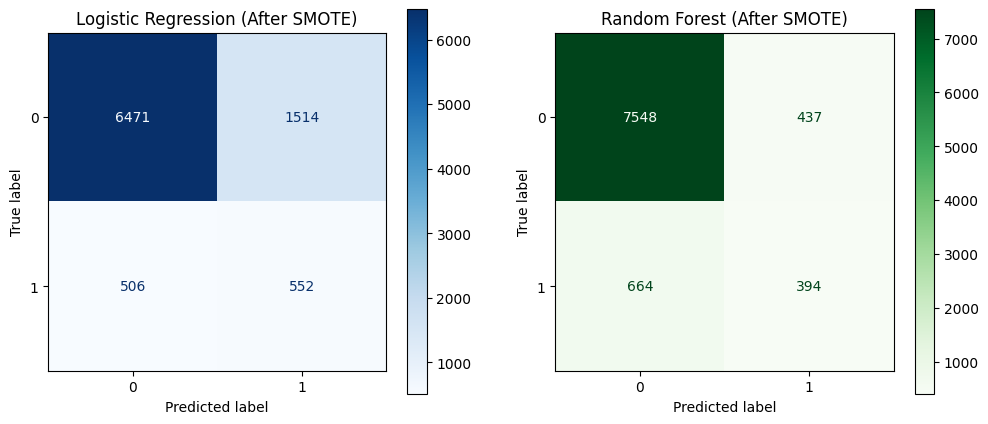

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression (After SMOTE)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest (After SMOTE)")
plt.show()

# ROC Curves

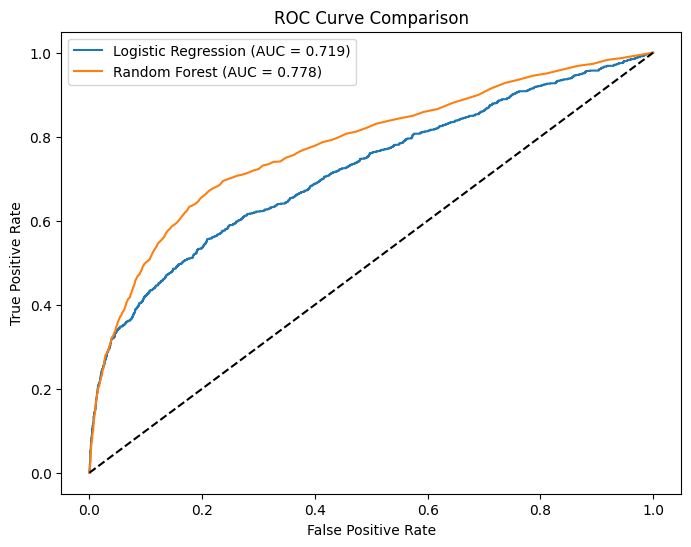

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# LIME Explainability (for Random Forest)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=afd1aeb2e715ab2064e4127cf8477cded431780bd2f76c20b6ff930dd6726107
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


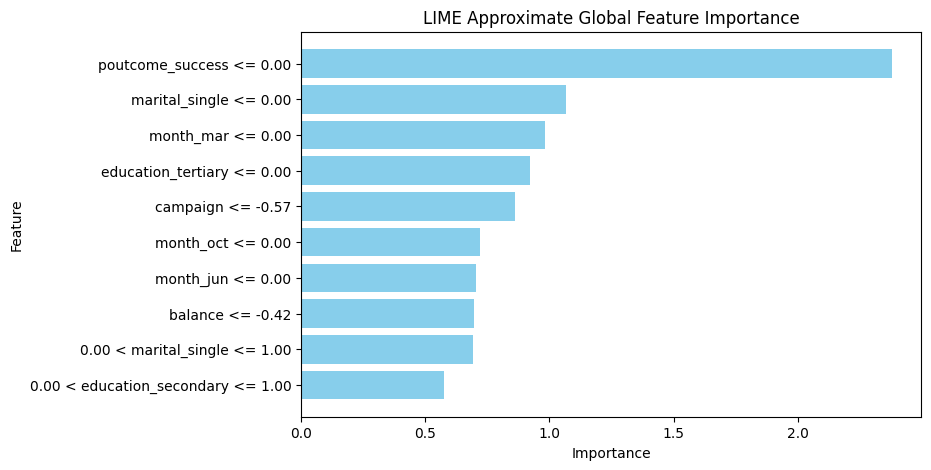


🔹 Explanation for instance 1263 (True label: 0)


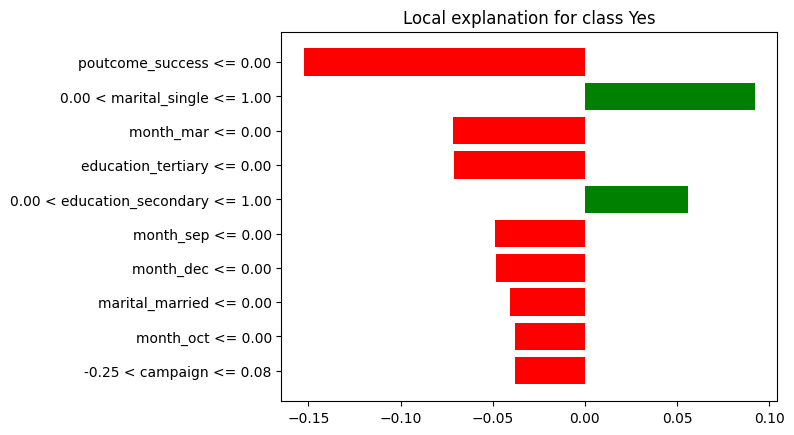


🔹 Explanation for instance 93 (True label: 0)


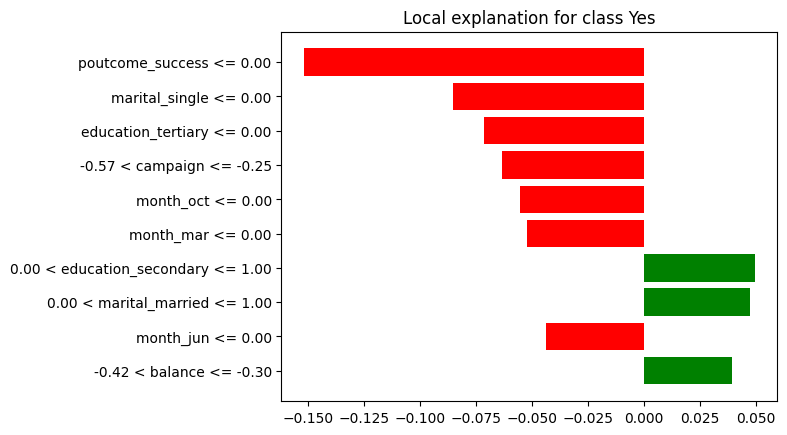


🔹 Explanation for instance 3316 (True label: 1)


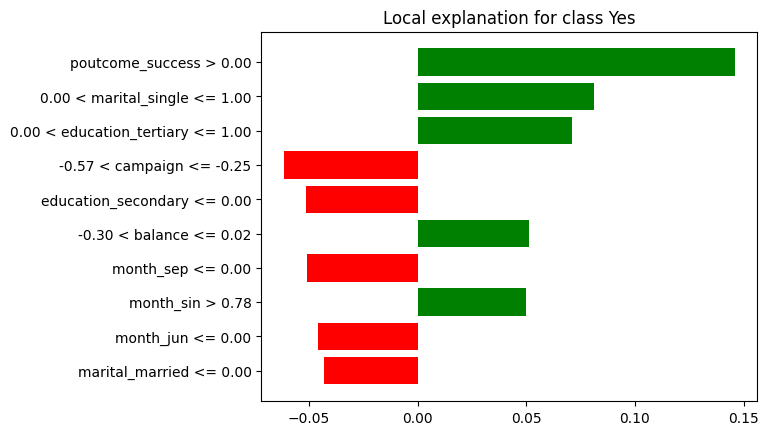


🔹 Explanation for instance 3027 (True label: 0)


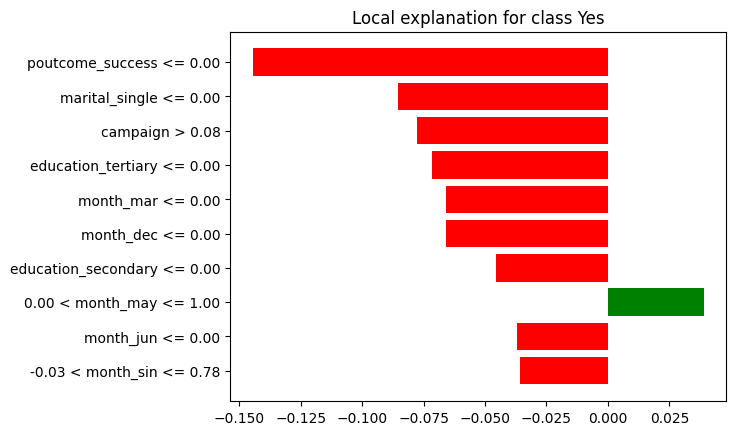


🔹 Explanation for instance 8360 (True label: 0)


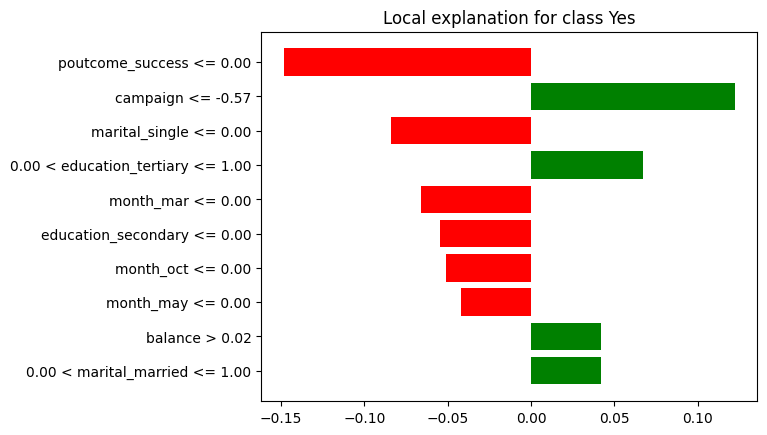

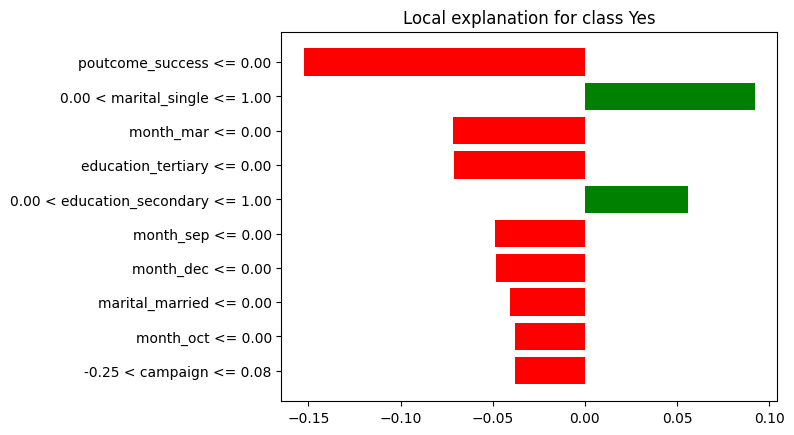

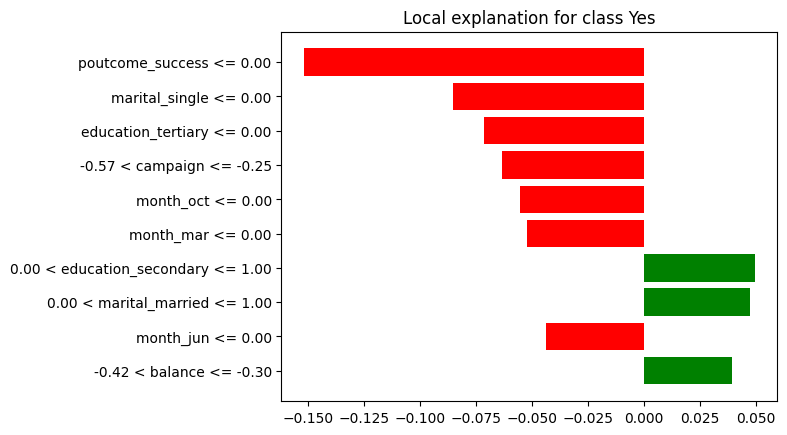

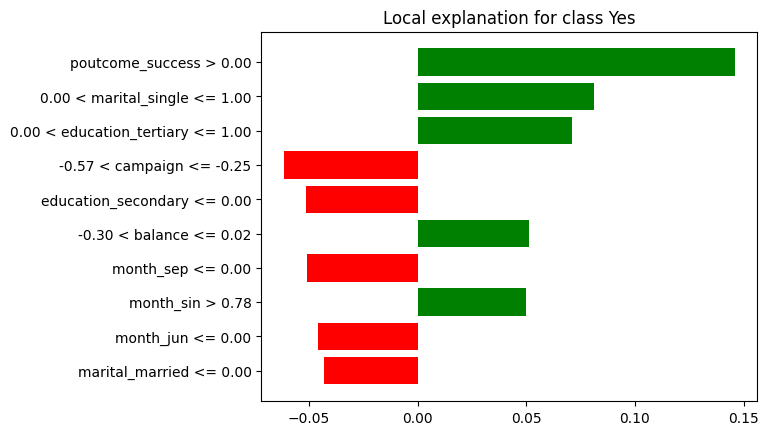

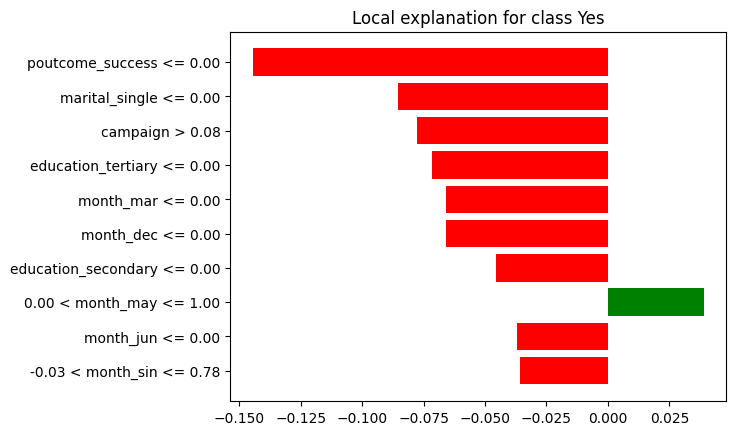

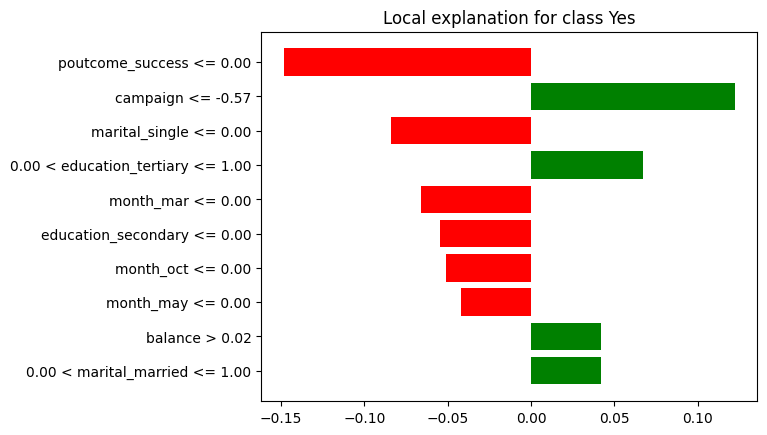

In [ ]:
# Install lime (if not installed)
!pip install lime

# Import
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt

# Create LIME explainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    mode='classification'
)

# --- 1️⃣ Global Explanation (Feature Importance Approximation)
# We'll average local explanations for a few random samples to estimate importance
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 20, replace=False)
feature_importances = {}

for i in sample_idx:
    exp = explainer.explain_instance(
        data_row=X_test.iloc[i],
        predict_fn=rf.predict_proba
    )
    for feature, weight in exp.as_list():
        feature_importances[feature] = feature_importances.get(feature, 0) + abs(weight)

# Convert to DataFrame
importance_df = pd.DataFrame(list(feature_importances.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('LIME Approximate Global Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# --- 2️⃣ Local Explanation (Explain 5 Random Predictions)
np.random.seed(42)
test_indices = np.random.choice(len(X_test), 5, replace=False)

for i in test_indices:
    exp = explainer.explain_instance(
        data_row=X_test.iloc[i],
        predict_fn=rf.predict_proba
    )
    print(f"\n🔹 Explanation for instance {i} (True label: {y_test.iloc[i]})")
    display(exp.as_pyplot_figure())
